# Investigating the Ramp problem

Pyro's compressible solver supports the problem ```ramp```, which is based on the Woodward & Colella 1984 test problem Double Mach Reflection of a Strong Shock [1]. This is an extension of the classic shock tube test for the accuracy of hydrodynamics solvers, where a shock, modeled by a high pressure, density, and velocity fluid on the left hand side, collides at an angle with a stationary normal pressure and density fluid on the right. This setup results in discontinuities, i.e. shocks and contact discontinuities. 

This problem is valuable for analyzing the effictiveness of how a solver handles discontinuities, since both shocks and contact discontinuities occur frequently in compressible hydrodynamics. 

Note: This is not a rigourous investigation of Pyro's performance on this problem. Instead we focus on how this problem is run as well as the purpose and value of running this test. 

## Setup

Since ```inputs.ramp``` is already set up for the Woodward and Colella [1] Double Mach Reflection problem, we can simply import it. This includes all of the specifications for the mesh, boundary conditions, and initial conditions like density, x velocity, y velocity, and pressure for both the left and right states. 

In [7]:
from pyro import Pyro

# Select solver, problem, and input file
solver = "compressible"
problem_name = "ramp"
param_file = "inputs.ramp"


# Initialize object
pyro_sim = Pyro(solver)
pyro_sim.initialize_problem(problem_name, inputs_file=param_file)

To see these values, we can print the state of the object.

In [8]:
print(pyro_sim)

Solver = compressible
Problem = ramp
Simulation time = 0.0
Simulation step number = 0

Runtime Parameters
------------------
compressible.cvisc = 0.1
compressible.delta = 0.33
compressible.grav = 0.0
compressible.limiter = 2
compressible.riemann = HLLC
compressible.small_dens = -1e+200
compressible.small_eint = -1e+200
compressible.use_flattening = 1
compressible.z0 = 0.75
compressible.z1 = 0.85
driver.cfl = 0.8
driver.fix_dt = -1.0
driver.init_tstep_factor = 0.01
driver.max_dt_change = 2.0
driver.max_steps = 12500
driver.tmax = 0.25
driver.verbose = 0
eos.gamma = 1.4
io.basename = double_mach_reflection_
io.do_io = 0
io.dt_out = 0.1
io.force_final_output = 0
io.n_out = 10000
mesh.grid_type = Cartesian2d
mesh.nx = 1024
mesh.ny = 256
mesh.xlboundary = ramp
mesh.xmax = 4.0
mesh.xmin = 0.0
mesh.xrboundary = outflow
mesh.ylboundary = ramp
mesh.ymax = 1.0
mesh.ymin = 0.0
mesh.yrboundary = ramp
particles.do_particles = 0
particles.n_particles = 100
particles.particle_generator = grid
ramp.pl

For more of a visual, we can plot the initial data. Here we can see the "at rest" right hand side of the shock tube as well as the shock on the left hand side hitting this stationary fluid. 

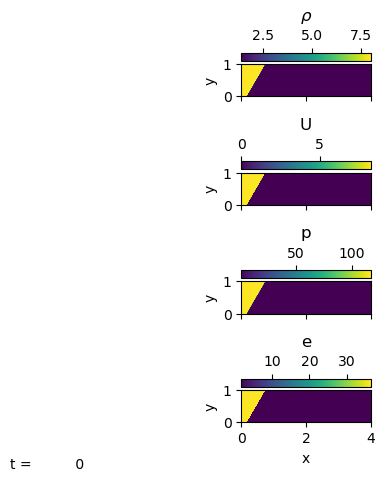

<Figure size 640x480 with 0 Axes>

In [9]:
pyro_sim.sim.dovis()

## Run Simulation

We can edit the parameters in a couple useful ways. First, we can make sure that it does not plot every time step by setting ```vis.dovis``` to ```False```. Second, we can decrease the number of time steps with ```driver.max_steps```. This ensures that the simulation runs in an appropriate amount of time at the cost of some accuracy. In this case, 500 is enough to see that the behavior starts to match what is expected from Woodward and Colella [1]. 

After changing these we need to re-initialize the problem, and then we can run it. 

In [ ]:
extra_parameters = {'vis.dovis': False, 'driver.max_steps': 500}
pyro_sim.initialize_problem(problem_name, inputs_file=param_file, inputs_dict=extra_parameters)
pyro_sim.run_sim()

Now, if we plot the solution, it will visualize the density $\rho$, the magnitude of the velocity $U = [u, v]^T$, the pressure $p$, and the internal energy $e$.

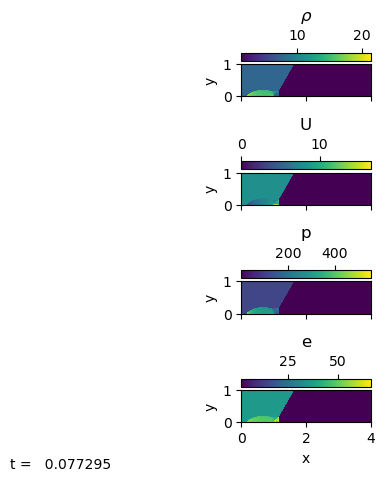

<Figure size 640x480 with 0 Axes>

In [19]:
pyro_sim.sim.dovis()

Since the equations are solving for the conserved quantities, i.e. density, momentum ($\rho U$), and total energy density ($\rho E$), some of these results require solving for other values. Pyro does this implicitly when calling ```dovis()```, but we can also do it on our own via ```cons_to_prim()```.

Here is an example of plotting just one of the outputs. Density ($\rho$) is shown since it is easy to visually compare with the results from Woodward and Colella [1]. They additionally show the rest of the primitive variables---density $\rho$, pressure $p$, x velocity $u$, and y velocity $v$---as well as a measure of specific entropy $p/\rho^\gamma$. 

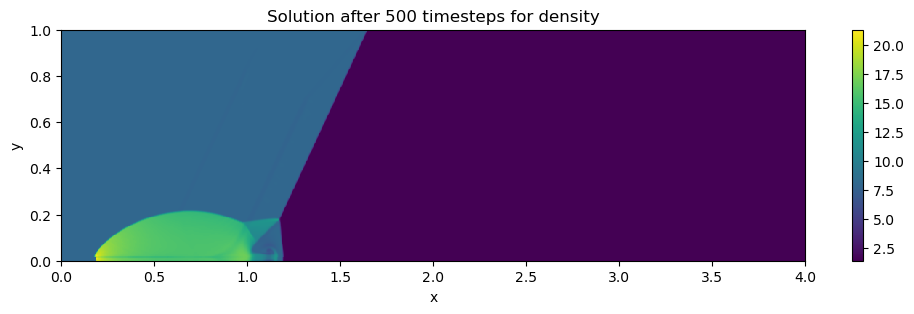

In [77]:
from pyro.compressible import simulation as s
from matplotlib import pyplot as plt

# Get outputs for plotting. Change into primitive variables for ease of use
conserved_data = pyro_sim.sim.cc_data
q = s.cons_to_prim(conserved_data.data, conserved_data.get_aux("gamma"), s.Variables(conserved_data), conserved_data.grid)

# Isolate variable to plot. If choosing another, replace name in pcolormesh and title
# p = q[:, :, s.Variables(conserved_data).ip] # Pressure
# u = q[:, :, s.Variables(conserved_data).iu] # x Velocity
# v = q[:, :, s.Variables(conserved_data).iv] # y Velocity
rho = q[:, :, s.Variables(conserved_data).irho] # Density

# Set up for plotting - necessary for plt.pcolormesh, relates to labeling axes correctly
myg = conserved_data.grid
x = myg.scratch_array()
y = myg.scratch_array()
x.v()[:, :] = myg.x2d.v()[:, :]
y.v()[:, :] = myg.y2d.v()[:, :]

# Plot
plt.figure(figsize=(12, 3))
plt.pcolormesh(x.v(), y.v(), rho[0:len(x.v()),0:len(x.v()[0])], shading="nearest", cmap=pyro_sim.sim.cm)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Solution after 500 timesteps for density")
plt.colorbar()
plt.show()

## Results

While 500 time steps is not enough to evolve the solution completely, it does resemble the results shown in Woodward and Colella [1]. The same sections within the shock can be identified, including the turbulent jet that forms near the bottom wall. This is an important feature, since it requires more resolution to accurately model. 

Pyro does not use one of the flux limiting schemes explicitly tested in Woodward and Colella [1]; instead, it uses a hybrid approach proposed by Colella in "Multidimensional upwind methods for hyperbolic conservation laws" [2]. However, the results are comparable, indicating that Pyro is adept at handling discontinuities.

For more information about the Double Mach Reflection problem, as well as an explanation of three different types of flux limiters and their performance on the problem, see "The Numerical Simulation of Two-Dimensional Fluid Flow with Strong Shocks" [1]. 

## References

[1] P.R. Woodward & P. Colella. The Numerical Simulation of Two-Dimensional Fluid Flow with Strong Shocks, *Journal of Computational Physics*, 54:115-173, April 1984. [10.1016/0021-9991(84)90142-6](10.1016/0021-9991(84)90142-6).

[2] P. Colella. Multidimensional upwind methods for hyperbolic conservation laws. *Journal of Computational Physics*, 87:171–200, March 1990. [doi:10.1016/0021-9991(90)90233-Q](doi:10.1016/0021-9991(90)90233-Q).